In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
sovitrath_diabetic_retinopathy_224x224_gaussian_filtered_path = kagglehub.dataset_download('sovitrath/diabetic-retinopathy-224x224-gaussian-filtered')

print('Data source import complete.')
print(sovitrath_diabetic_retinopathy_224x224_gaussian_filtered_path)

Data source import complete.
/kaggle/input/diabetic-retinopathy-224x224-gaussian-filtered


In [2]:
import os
import shutil

# Répertoires
source_dir = '/kaggle/input/diabetic-retinopathy-224x224-gaussian-filtered/gaussian_filtered_images/gaussian_filtered_images'
target_dir = '/content/images'

# Dictionnaire de renommage
rename_dict = {
    'Mild': '1_Mild',
    'Moderate': '2_Moderate',
    'No_DR': '0_No_DR',
    'Proliferate_DR': '4_Proliferate_DR',
    'Severe': '3_Severe'
}

# Créer le dossier cible
os.makedirs(target_dir, exist_ok=True)

# Copier et renommer les dossiers
for old_name, new_name in rename_dict.items():
    old_path = os.path.join(source_dir, old_name)
    new_path = os.path.join(target_dir, new_name)

    if os.path.exists(old_path):
        shutil.copytree(old_path, new_path)
        print(f'Copié et renommé : {old_name} → {new_name}')
    else:
        print(f'Dossier introuvable : {old_path}')


Copié et renommé : Mild → 1_Mild
Copié et renommé : Moderate → 2_Moderate
Copié et renommé : No_DR → 0_No_DR
Copié et renommé : Proliferate_DR → 4_Proliferate_DR
Copié et renommé : Severe → 3_Severe


In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import pandas as pd
import random, os
import shutil
import matplotlib.pyplot as plt
from matplotlib.image import imread
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.metrics import categorical_accuracy
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

In [4]:
df = pd.read_csv(r'/kaggle/input/diabetic-retinopathy-224x224-gaussian-filtered/train.csv')

diagnosis_dict_binary = {
    0: 'No_DR',
    1: 'DR',
    2: 'DR',
    3: 'DR',
    4: 'DR'
}

diagnosis_dict = {
    0: '0_No_DR',
    1: '1_Mild',
    2: '2_Moderate',
    3: '3_Severe',
    4: '4_Proliferate_DR',
}

path = '/content/images'
df['binary_type'] =  df['diagnosis'].map(diagnosis_dict_binary.get)
df['type'] = df['diagnosis'].map(diagnosis_dict.get)
df['filename'] = path + '/' + df['type'] + '/' + df['id_code'] + '.png'
df.head()

,id_code,diagnosis,binary_type,type,filename
0,000c1434d8d7,2,DR,2_Moderate,/content/images/2_Moderate/000c1434d8d7.png
1,001639a390f0,4,DR,4_Proliferate_DR,/content/images/4_Proliferate_DR/001639a390f0.png
2,0024cdab0c1e,1,DR,1_Mild,/content/images/1_Mild/0024cdab0c1e.png
3,002c21358ce6,0,No_DR,0_No_DR,/content/images/0_No_DR/002c21358ce6.png
4,005b95c28852,0,No_DR,0_No_DR,/content/images/0_No_DR/005b95c28852.png


<Axes: ylabel='type'>

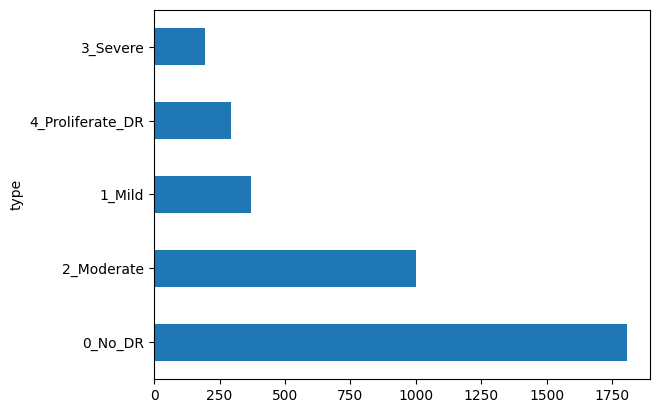

In [5]:
df['type'].value_counts().plot(kind='barh')

<Axes: ylabel='binary_type'>

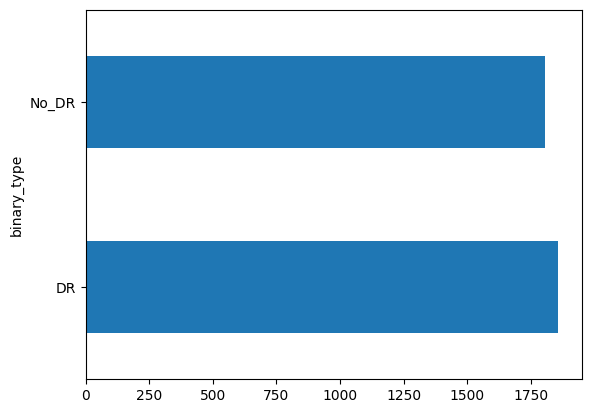

In [6]:
df['binary_type'].value_counts().plot(kind='barh')

In [7]:
train_intermediate, test = train_test_split(df, test_size = 0.15, stratify = df['type'])
train, val = train_test_split(train_intermediate, test_size = 0.15 / (1 - 0.15), stratify = train_intermediate['type'])

print("Train shape: ", train.shape)
print("Test shape: ",test.shape)
print("Valid shape: ", val.shape)

print(train['type'].value_counts(), '\n')
print(test['type'].value_counts(), '\n')
print(val['type'].value_counts(), '\n')

Train shape:  (2562, 5)
Test shape:  (550, 5)
Valid shape:  (550, 5)
type
0_No_DR             1263
2_Moderate           699
1_Mild               258
4_Proliferate_DR     207
3_Severe             135
Name: count, dtype: int64 

type
0_No_DR             271
2_Moderate          150
1_Mild               56
4_Proliferate_DR     44
3_Severe             29
Name: count, dtype: int64 

type
0_No_DR             271
2_Moderate          150
1_Mild               56
4_Proliferate_DR     44
3_Severe             29
Name: count, dtype: int64 



In [8]:
train_path1 = '/content/images'

train_datagen = ImageDataGenerator(
    rescale=1./255,
)
# Générateur sans augmentation pour validation et test
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_batches = train_datagen.flow_from_dataframe(
    dataframe=train,
    directory=train_path1,
    x_col='filename',
    y_col='type',
    target_size=(224, 224),
    class_mode='categorical',
    shuffle=True,
    batch_size=32
)

val_batches = val_datagen.flow_from_dataframe(
    dataframe=val,
    directory=train_path1,
    x_col='filename',
    y_col='type',
    target_size=(224, 224),
    class_mode='categorical',
    shuffle=True,
    batch_size=32)

test_batches = test_datagen.flow_from_dataframe(
    dataframe=test,
    directory=train_path1,
    x_col='filename',
    y_col='type',
    target_size=(224, 224),
    class_mode='categorical',
    shuffle=False,
    batch_size=32)

Found 2562 validated image filenames belonging to 5 classes.
Found 550 validated image filenames belonging to 5 classes.
Found 550 validated image filenames belonging to 5 classes.


In [9]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Flatten
from tensorflow.keras.optimizers import Adam

base_model = MobileNetV2(include_top=False, weights='imagenet', input_shape=(224, 224, 3))

# Gèle les couches du modèle de base
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.2)(x)
predictions = Dense(5, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
              loss=tf.keras.losses.CategoricalCrossentropy(),
              metrics=['accuracy'])

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,597 (9.24 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [10]:
history = model.fit(train_batches,
                    epochs=50,
                    validation_data=val_batches,
                    )

Epoch 1/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 29s 220ms/step - accuracy: 0.4646 - loss: 1.4706 - val_accuracy: 0.7236 - val_loss: 0.8260
Epoch 2/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 8s 103ms/step - accuracy: 0.6701 - loss: 0.9668 - val_accuracy: 0.7473 - val_loss: 0.7537
Epoch 3/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 9s 105ms/step - accuracy: 0.6992 - loss: 0.8727 - val_accuracy: 0.7564 - val_loss: 0.7209
Epoch 4/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 8s 99ms/step - accuracy: 0.7062 - loss: 0.8409 - val_accuracy: 0.7618 - val_loss: 0.7038
Epoch 5/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 8s 104ms/step - accuracy: 0.7123 - loss: 0.8197 - val_accuracy: 0.7655 - val_loss: 0.6987
Epoch 6/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 8s 101ms/step - accuracy: 0.7200 - loss: 0.7820 - val_accuracy: 0.7582 - val_loss: 0.6905
Epoch 7/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 10s 98ms/step - accuracy: 0.7349 - loss: 0.7586 - val_accuracy: 0.7600 - val_loss: 0.6777
Epoch 8/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 8s 103ms/step - accuracy: 0.7519 - loss: 0.7284 - val_accuracy: 0.

In [15]:
model.save('MobileNetV2_model.h5')

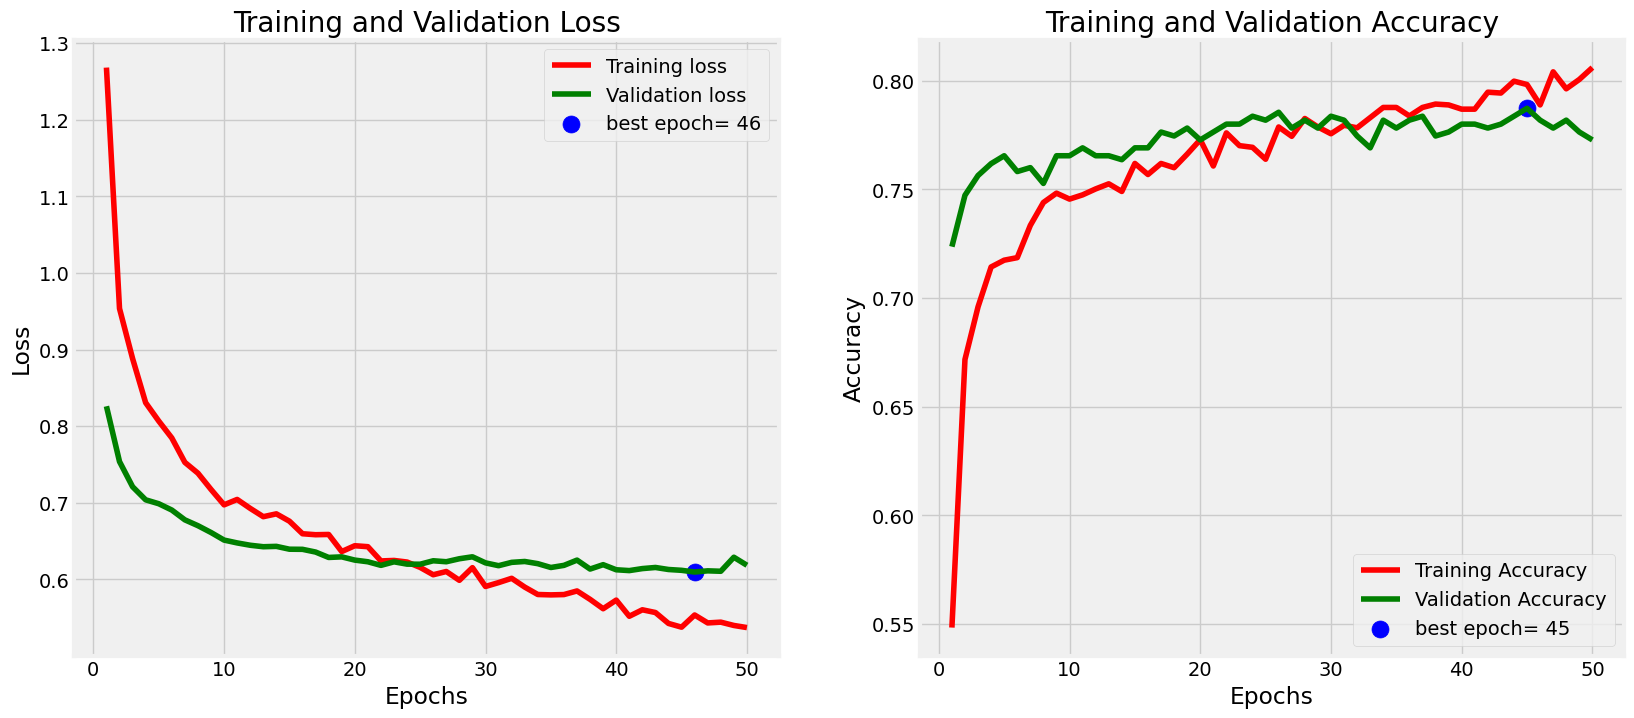

In [11]:
# Define needed variables
tr_acc = history.history['accuracy']
tr_loss = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']

index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]
index_acc = np.argmax(val_acc)
acc_highest = val_acc[index_acc]
Epochs = [i+1 for i in range(len(tr_acc))]
loss_label = f'best epoch= {str(index_loss + 1)}'
acc_label = f'best epoch= {str(index_acc + 1)}'

# Plot training history
plt.figure(figsize= (20, 8))
plt.style.use('fivethirtyeight')

plt.subplot(1, 2, 1)
plt.plot(Epochs, tr_loss, 'r', label= 'Training loss')
plt.plot(Epochs, val_loss, 'g', label= 'Validation loss')
plt.scatter(index_loss + 1, val_lowest, s= 150, c= 'blue', label= loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(Epochs, tr_acc, 'r', label= 'Training Accuracy')
plt.plot(Epochs, val_acc, 'g', label= 'Validation Accuracy')
plt.scatter(index_acc + 1 , acc_highest, s= 150, c= 'blue', label= acc_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout
plt.show()

In [12]:
train_score = model.evaluate(train_batches, verbose= 1)
valid_score = model.evaluate(val_batches, verbose= 1)
test_score = model.evaluate(test_batches, verbose= 1)

print("Train Loss: ", train_score[0])
print("Train Accuracy: ", train_score[1])
print('-' * 20)
print("Validation Loss: ", valid_score[0])
print("Validation Accuracy: ", valid_score[1])
print('-' * 20)
print("Test Loss: ", test_score[0])
print("Test Accuracy: ", test_score[1])

81/81 ━━━━━━━━━━━━━━━━━━━━ 9s 105ms/step - accuracy: 0.8280 - loss: 0.4812
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - accuracy: 0.7819 - loss: 0.6180
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step - accuracy: 0.7444 - loss: 0.6458
Train Loss:  0.4589710831642151
Train Accuracy:  0.8360655903816223
--------------------
Validation Loss:  0.6184084415435791
Validation Accuracy:  0.7727272510528564
--------------------
Test Loss:  0.6022707223892212
Test Accuracy:  0.7690908908843994


18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 232ms/step


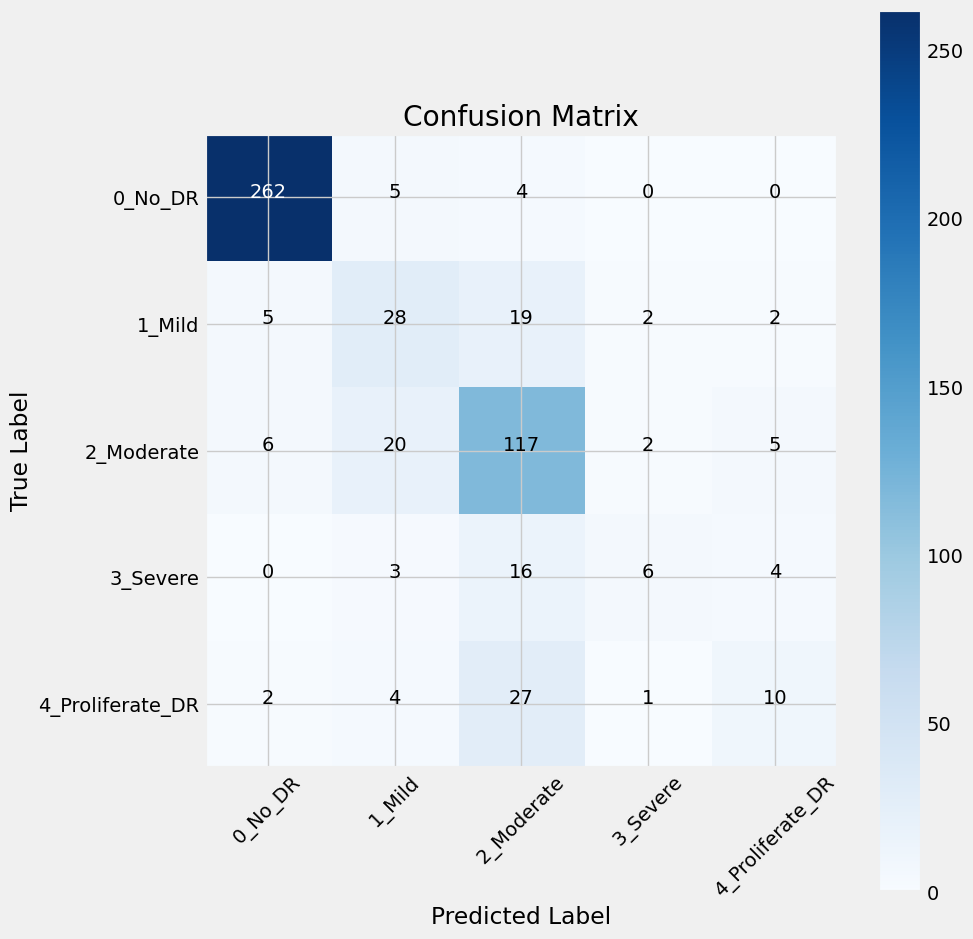

In [13]:
from sklearn.metrics import confusion_matrix, classification_report
import itertools

preds = model.predict(test_batches, steps=len(test_batches))
y_pred = np.argmax(preds, axis=1)

g_dict = test_batches.class_indices
classes = list(g_dict.keys())

# Confusion matrix
cm = confusion_matrix(test_batches.classes, y_pred)

plt.figure(figsize= (10, 10))
plt.imshow(cm, interpolation= 'nearest', cmap= plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation= 45)
plt.yticks(tick_marks, classes)

thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j], horizontalalignment= 'center', color= 'white' if cm[i, j] > thresh else 'black')

plt.tight_layout()
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.show()

In [14]:
# Classification report
print(classification_report(test_batches.classes, y_pred, target_names= classes))

                  precision    recall  f1-score   support

         0_No_DR       0.95      0.97      0.96       271
          1_Mild       0.47      0.50      0.48        56
      2_Moderate       0.64      0.78      0.70       150
        3_Severe       0.55      0.21      0.30        29
4_Proliferate_DR       0.48      0.23      0.31        44

        accuracy                           0.77       550
       macro avg       0.62      0.54      0.55       550
    weighted avg       0.76      0.77      0.75       550

